## Modelling Cyclist Volume of Greater Adelaide using Ordinary Least Squares
__OSM Region:__ Adelaide city boundary (OSM Relation 11381689)
This acutally doesn't perfectly overlap with GCCSA for Greater Adelaide, it spans further South/North and excludes the hills but we can trim down by MB to get a decent region still.

__MB Table Builder Rows:__ MB by Greater Capital City Statistical Areas (UR) -> SA -> Greater Adelaide MB

__MB Col Sets:__ (may not use all)
- HEAP Level of Highest Educational Attainment
- EETP Engagement in Employment, Education and Training
- Hours Worked (ranges)
- Full time workers
- Method of travel to work

__DZN Table Builder Rows:__ Greater Capital City Statistical Areas (POW) -> SA -> Greater Adelaide DZN

__DZN Col Sets:__
- HEAP Level of Highest Educational Attainment
- EETP Engagement in Employment, Education and Training
- Method of Travel to work

__Infrastructure Data:__
```py
infrastructure_tags = {
    "highway": ["cycleway"],
    "cycleway": True,
    "cycleway:left": True,
    "cycleway:right": True,
    "cycleway:both": True,
    "bicycle": True,
    # Can add many more
}
```
- Distance from CBD (distance from inner polygon?)

__Count Data:__
- Super Tuesday 2019-2026 but may only use 2026 cos others are outdated

In [1]:
import sys
!{sys.executable} -m pip install --quiet osmnx networkx matplotlib

In [2]:
import osmnx as ox
import matplotlib.pyplot as plt
import geopandas as gpd

ox.settings.log_console = True
ox.settings.use_cache = True

__*Define Greater Adelaide Region and Create Graph*__

In [4]:
gdf_boundary = ox.geocode_to_gdf("R11381689", by_osmid=True)
polygon = gdf_boundary.geometry.iloc[0]

G = ox.graph_from_polygon(polygon, network_type="bike")
print(f"Nodes: {len(G.nodes)}. Edges: {len(G.edges)}")
print(gdf_boundary.display_name[0])

Nodes: 122277. Edges: 291701
Adelaide, South Australia, Australia


__*Preliminary Node Network*__

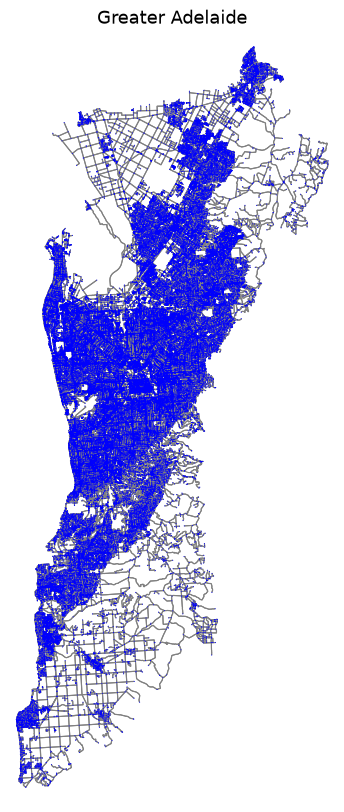

In [6]:
fig, ax = ox.plot_graph(
    G,
    node_size=0.5,
    node_color="blue",
    node_zorder=3,
    edge_color="gray",
    edge_linewidth=0.8,
    bgcolor="white",
    figsize=(10, 10),
    show=False,
    close=False,
)
ax.set_title("Greater Adelaide", fontsize=13)
plt.show()

__*Import Street Infrastructure Data*__

In [7]:
import networkx as nx

infrastructure_tags = {
    "highway": ["cycleway"],
    "cycleway": True,
    "cycleway:left": True,
    "cycleway:right": True,
    "cycleway:both": True,
    "bicycle": True,
}

infrastructure_data = ox.features_from_polygon(
    polygon,
    tags=infrastructure_tags,
)

nodes_gdf, edges_gdf = ox.graph_to_gdfs(
    G,
    nodes=True,
    edges=True,
)

# Match infrastructure geometries to graph edges.
infrastructure_data = infrastructure_data[
    infrastructure_data.geometry.notna()
].to_crs(edges_gdf.crs).copy()
infrastructure_data["_has_infrastructure"] = True

edge_infrastructure_matches = gpd.sjoin(
    edges_gdf[["geometry"]],
    infrastructure_data[["_has_infrastructure", "geometry"]],
    how="left",
    predicate="intersects",
)

matched_edges = edge_infrastructure_matches.loc[
    edge_infrastructure_matches["_has_infrastructure"].eq(True)
].index.unique()

nx.set_edge_attributes(G, False, "HAS_BICYCLE_INFRASTRUCTURE")

for source, target, key in matched_edges:
    G.edges[source, target, key]["HAS_BICYCLE_INFRASTRUCTURE"] = True

print(f"Edges with infrastructure: {len(matched_edges)} / {len(edges_gdf)}")

Edges with infrastructure: 87166 / 291701


__*Load Mesh Blocks and Destination Zones*__

In [8]:
mbs_aus = gpd.read_file("../all-data/australia-mesh-blocks-raw/MB_2021_AUST_GDA2020.shp")
dzns_aus = gpd.read_file("../all-data/australia-destination-zones-raw/DZN_2021_AUST_GDA2020.shp")

mb_gdf_boundary_crs = gdf_boundary.to_crs(mbs_aus.crs)
dzn_gdf_boundary_crs = gdf_boundary.to_crs(dzns_aus.crs)
mbs = gpd.clip(mbs_aus, mb_gdf_boundary_crs)
dzns = gpd.clip(dzns_aus, dzn_gdf_boundary_crs)

print('MB all count: ', len(mbs_aus))
print('MB Adelaide count: ', len(mbs))
print('DZN all count: ', len(dzns_aus))
print('DZN Adelaide count: ', len(dzns))

MB all count:  368286
MB Adelaide count:  18263
DZN all count:  9329
DZN Adelaide count:  479


__*Join Mesh Blocks and Destination Zones into Graph*__

In [9]:
nodes_gdf = ox.graph_to_gdfs(G, nodes=True, edges=False)[["geometry"]]

nodes_mbs = gpd.sjoin(
    nodes_gdf.to_crs(mbs.crs),
    mbs[["MB_CODE21", "geometry"]],
    how="left",
    predicate="within",
)
node_mb_codes = nodes_mbs["MB_CODE21"].dropna().to_dict()
nx.set_node_attributes(G, node_mb_codes, "MB_CODE21")

nodes_dzns = gpd.sjoin(
    nodes_gdf.to_crs(dzns.crs),
    dzns[["DZN_CODE21", "geometry"]],
    how="left",
    predicate="within",
)
node_dzn_codes = nodes_dzns["DZN_CODE21"].dropna().to_dict()
nx.set_node_attributes(G, node_dzn_codes, "DZN_CODE21")

print(f"Graph nodes: {len(G.nodes)}")
print(f"Nodes with MB_CODE21: {len(node_mb_codes)}")
print(f"Nodes with DZN_CODE21: {len(node_dzn_codes)}")

Graph nodes: 122277
Nodes with MB_CODE21: 122258
Nodes with DZN_CODE21: 122258
